In [1]:
pip install pandas numpy scikit-learn nltk

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import re
import nltk

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [3]:
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Snehal\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df = pd.read_csv("IMDB Dataset.csv")

print(df.head())
print(df['sentiment'].value_counts())


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [5]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()

def preprocess_text(text):
    # Lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z]', ' ', text)

    # Tokenization
    words = text.split()

    # Remove stopwords and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]

    return " ".join(words)


In [6]:
df['cleaned_review'] = df['review'].apply(preprocess_text)

print(df[['review', 'cleaned_review']].head())


                                              review  \
0  One of the other reviewers has mentioned that ...   
1  A wonderful little production. <br /><br />The...   
2  I thought this was a wonderful way to spend ti...   
3  Basically there's a family where a little boy ...   
4  Petter Mattei's "Love in the Time of Money" is...   

                                      cleaned_review  
0  one review mention watch oz episod hook right ...  
1  wonder littl product film techniqu unassum old...  
2  thought wonder way spend time hot summer weeke...  
3  basic famili littl boy jake think zombi closet...  
4  petter mattei love time money visual stun film...  


In [7]:
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['cleaned_review'])
y = df['sentiment']


In [8]:
y = y.map({'positive': 1, 'negative': 0})


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [11]:
y_pred = model.predict(X_test)


In [12]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.8864
Precision: 0.8765193903144897
Recall: 0.901567771383211
F1-Score: 0.8888671492858541

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.87      0.88      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [13]:
custom_review = "This movie was a complete waste of time, the acting was wooden."

clean_review = preprocess_text(custom_review)

custom_vec = vectorizer.transform([clean_review])

prediction = model.predict(custom_vec)

if prediction[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")


Sentiment: Negative


In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [15]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)


Confusion Matrix:
[[4321  640]
 [ 496 4543]]


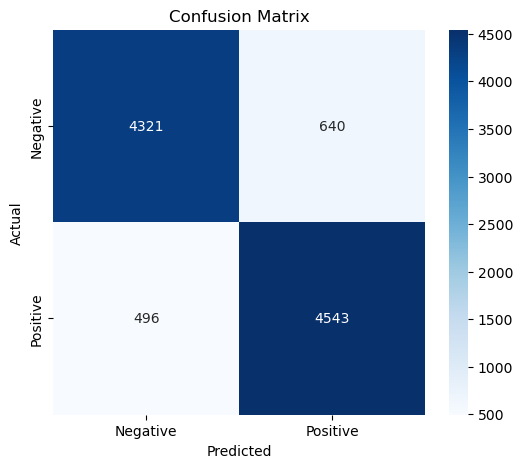

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


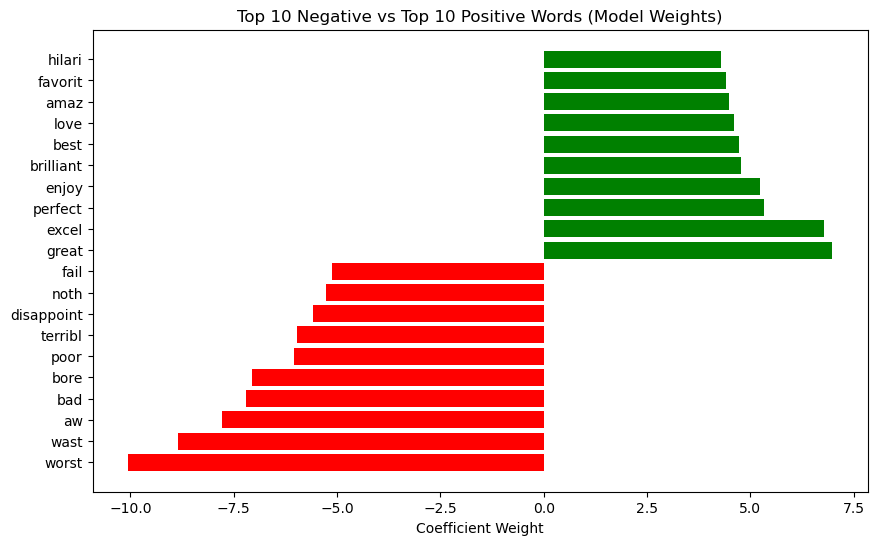

In [17]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = vectorizer.get_feature_names_out()

coefficients = model.coef_[0]

coef_df = pd.DataFrame({'word': feature_names, 'weight': coefficients})

top_positive = coef_df.sort_values(by='weight', ascending=False).head(10)
top_negative = coef_df.sort_values(by='weight', ascending=True).head(10)

top_words = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10, 6))
colors = ['red' if x < 0 else 'green' for x in top_words['weight']]
plt.barh(top_words['word'], top_words['weight'], color=colors)
plt.title('Top 10 Negative vs Top 10 Positive Words (Model Weights)')
plt.xlabel('Coefficient Weight')
plt.show()


In [18]:
#Naive Bayes
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [19]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)


MultinomialNB()

In [20]:
y_pred_nb = nb_model.predict(X_test)


In [21]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb)
recall_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)

print("Naive Bayes Results")
print("Accuracy:", accuracy_nb)
print("Precision:", precision_nb)
print("Recall:", recall_nb)
print("F1-Score:", f1_nb)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Results
Accuracy: 0.8514
Precision: 0.8471760797342193
Recall: 0.8602897400277832
F1-Score: 0.8536825521859

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.84      0.85      4961
           1       0.85      0.86      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [22]:
cm_nb = confusion_matrix(y_test, y_pred_nb)

print("Confusion Matrix:\n", cm_nb)


Confusion Matrix:
 [[4179  782]
 [ 704 4335]]


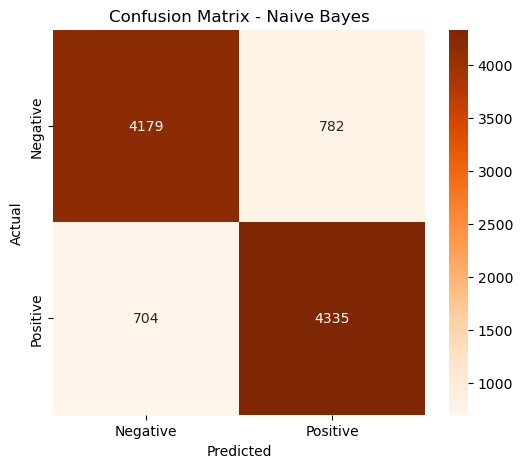

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()


In [24]:
custom_review = "This movie was a complete waste of time, the acting was wooden."

clean_review = preprocess_text(custom_review)

custom_vec = vectorizer.transform([clean_review])

prediction_nb = nb_model.predict(custom_vec)

if prediction_nb[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")


Sentiment: Negative


In [25]:
#SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [26]:
svm_model = LinearSVC()

svm_model.fit(X_train, y_train)


LinearSVC()

In [27]:
y_pred_svm = svm_model.predict(X_test)


In [28]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("SVM Results")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1-Score:", f1_svm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))


SVM Results
Accuracy: 0.8806
Precision: 0.8726497383213802
Recall: 0.89343123635642
F1-Score: 0.8829182192586782

Classification Report:

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.87      0.89      0.88      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



In [29]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

print("Confusion Matrix:\n", cm_svm)


Confusion Matrix:
 [[4304  657]
 [ 537 4502]]


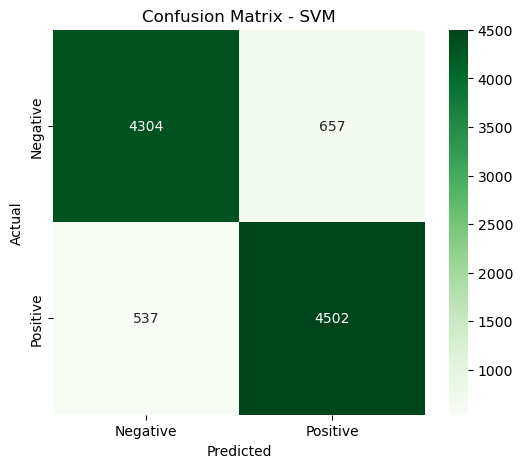

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM')
plt.show()


In [31]:
custom_review = "This movie was a complete waste of time, the acting was wooden."

clean_review = preprocess_text(custom_review)

custom_vec = vectorizer.transform([clean_review])

prediction_svm = svm_model.predict(custom_vec)

if prediction_svm[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")


Sentiment: Negative


In [32]:
#rANDOM fOREST
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report


In [33]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

In [34]:
y_pred_rf = rf_model.predict(X_test)


In [35]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Results")
print("Accuracy:", accuracy_rf)
print("Precision:", precision_rf)
print("Recall:", recall_rf)
print("F1-Score:", f1_rf)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))


Random Forest Results
Accuracy: 0.8485
Precision: 0.8563915857605178
Recall: 0.8402460805715419
F1-Score: 0.848242011419413

Classification Report:

              precision    recall  f1-score   support

           0       0.84      0.86      0.85      4961
           1       0.86      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



In [36]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Confusion Matrix:\n", cm_rf)


Confusion Matrix:
 [[4251  710]
 [ 805 4234]]


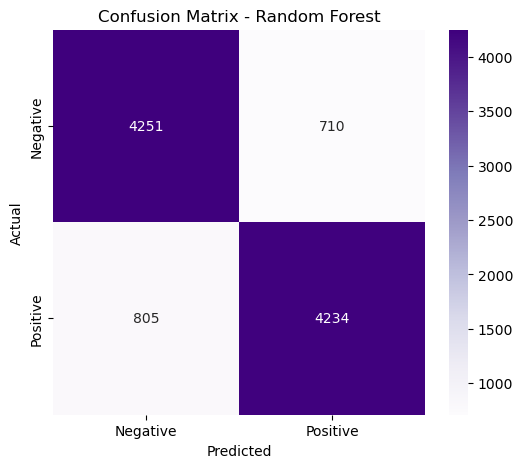

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.show()


In [38]:
custom_review = "This movie was a complete waste of time, the acting was wooden."

clean_review = preprocess_text(custom_review)

custom_vec = vectorizer.transform([clean_review])

prediction_rf = rf_model.predict(custom_vec)

if prediction_rf[0] == 1:
    print("Sentiment: Positive")
else:
    print("Sentiment: Negative")


Sentiment: Negative


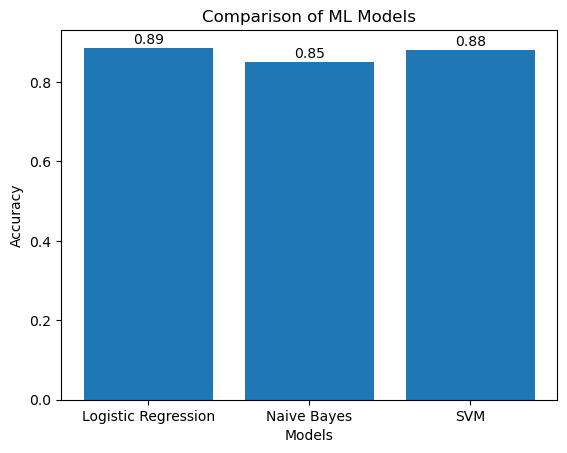

In [39]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Ensure all accuracies are defined properly

# Logistic Regression
accuracy_lr = accuracy_score(y_test, y_pred)

# Naive Bayes
accuracy_nb = accuracy_score(y_test, y_pred_nb)

# SVM
accuracy_svm = accuracy_score(y_test, y_pred_svm)

# Store values
models = ['Logistic Regression', 'Naive Bayes', 'SVM']
accuracies = [accuracy_lr, accuracy_nb, accuracy_svm]

# Plot graph
plt.figure()
plt.bar(models, accuracies)

# Labels
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Comparison of ML Models")

# Show values on top
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()